In [1]:
# Copyright (c) 2025, TU Wien
# All rights reserved.

# THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
# AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
# IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE
# ARE DISCLAIMED. IN NO EVENT SHALL TU WIEN BE LIABLE FOR ANY DIRECT, INDIRECT,
# INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT
# LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA,
# OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF
# LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING
# NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE,
# EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.

In [2]:
#%pip install plotly
#%pip install nbformat
#%pip install geopy

In [156]:
import re
import os
import pickle
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import plotly.express as px
from scat_data_science.data_io.ascat_readers import AscatH121DynSlope
from scat_data_science.data_io.lsm_readers import Era5
from scat_data_science.data_io.veg_readers import Modis_MOD15A2H

def read_data(gpi):
    """Simple reader."""
    read_bulk = False
    sampling = 12.5

    ascat = AscatH121DynSlope(read_bulk=read_bulk)
    era5 = Era5(read_bulk=read_bulk)
    modis = Modis_MOD15A2H()

    ts_ascat = ascat.read(gpi)
    lon, lat = ascat.grid.gpi2lonlat(gpi)
    ts_era5 = era5.read(lon, lat)
    ts_veg = modis.read(lon, lat)

    tolerance = pd.Timedelta("6h")
    ts = pd.merge_asof(ts_ascat,
                       ts_era5,
                       left_index=True,
                       right_index=True,
                       tolerance=tolerance,
                       direction="nearest")

    tolerance = pd.Timedelta("8D")
    ts = pd.merge_asof(ts,
                       ts_veg,
                       left_index=True,
                       right_index=True,
                       tolerance=tolerance,
                       direction="nearest")

    lon, lat = ascat.grid.gpi2lonlat(gpi)
    loc_info = f"GPI: {gpi} FibGrid: {sampling} km\n Longitude: {lon:3.3f} Latitude: {lat:3.3f}"
    gpi_info = {"gpi": gpi, "FibGrid": sampling, "lon": lon, "lat": lat}
    return ts, loc_info, gpi_info



def format_date(xticks, pos=None):
    """
    Format date of axis.

    Parameters
    ----------
    xticks : numpy.ndarray
        xticks
    """
    dt = mdates.num2date(xticks)

    if dt.month == 7:
        fmt = "%Y"
        # fmt = "%m\n%Y"
        return f"{dt.strftime(fmt)}"
    else:
        return ""
        # fmt = "%m"
        # return f"{dt.strftime(fmt)}"


def format_date_month(xticks, pos=None):
    """
    Format date of axis.

    Parameters
    ----------
    xticks : numpy.ndarray
        xticks
    """
    dt = mdates.num2date(xticks)

    if dt.month == 1:
        fmt = "%b\n%Y"
        return f"{dt.strftime(fmt)}"
    else:
        fmt = "%b"
        return f"{dt.strftime(fmt)}"


def format_axis(ax):
    """Format axis"""
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mticker.NullFormatter())

    ax.xaxis.set_minor_locator(mdates.MonthLocator(range(1, 13, 3)))
    ax.xaxis.set_minor_formatter(mticker.FuncFormatter(format_date))

    ax.grid(True)


def format_axis_month(ax):
    """Format axis"""
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_date_month))

    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.xaxis.set_minor_formatter(mticker.FuncFormatter(format_date_month))

    ax.grid(True)


def simple_plot(ts, loc_info, cols):
    """Simple time series plots."""

    figsize = (12, 2*len(cols))
    fig, ax = plt.subplots(len(cols), 1, figsize=figsize, sharex=True)
    fig.suptitle(loc_info)
    if len(cols) == 1:
        ax = [ax]

    kwargs = {
        "marker": "o",
        "ls": "none",
        "fillstyle": "none",
        "markersize": 4,
        "alpha": 0.5
    }

    for i in range(len(cols)):
        ax[i].plot(ts[cols[i]], label=cols[i], **kwargs)
        ax[i].set_ylabel(cols[i])

    for i in range(len(ax)):
        ax[i].legend()
        format_axis(ax[i])

    plt.tight_layout()


def plot_model_reuse(df_results):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), 
                                   subplot_kw={'projection': ccrs.PlateCarree()})
    
    def setup_map(ax):
        ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='azure')
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_aspect('equal', adjustable='datalim')

    origin_point = df_results[df_results['is_origin'] == True]
    
    # --- LEFT MAP: CONTINUOUS DIFFICULTY ---
    setup_map(ax1)
    scale = 100
    scatter1 = ax1.scatter(
        df_results['Long'], df_results['Lat'],
        s=150,
        c=df_results['Difficulty_Index'], 
        cmap='YlOrRd',                   
        transform=ccrs.PlateCarree(),
        zorder=5, alpha=0.8,
        edgecolor='black', linewidth=0.3
    )

    # Highlight Origin
    if not origin_point.empty:
        origin_handle = ax1.scatter(
            origin_point['Long'], origin_point['Lat'],
            s=600, facecolors='none', edgecolors='magenta', 
            linewidth=3, marker='o', transform=ccrs.PlateCarree(), zorder=10,
            label='Training Origin'
        )

    cbar1 = plt.colorbar(scatter1, ax=ax1, orientation='vertical', shrink=0.7)
    cbar1.set_label('Difficulty Index (Color Scale)', rotation=270, labelpad=15)
    ax1.set_title("1. Local Difficulty Index", fontsize=14)

    # --- RIGHT MAP: PERFORMANCE LOSS ---
    setup_map(ax2)
    scatter2 = ax2.scatter(
        df_results['Long'], df_results['Lat'],
        s=150,
        c=df_results['rmse_loss_pct'], 
        cmap='YlOrRd', 
        transform=ccrs.PlateCarree(),
        zorder=5, edgecolor='black', linewidth=0.5
    )

    if not origin_point.empty:
        ax2.scatter(
            origin_point['Long'], origin_point['Lat'],
            s=600, facecolors='none', edgecolors='magenta', 
            linewidth=3, marker='o', transform=ccrs.PlateCarree(), zorder=10
        )

    cbar2 = plt.colorbar(scatter2, ax=ax2, orientation='vertical', shrink=0.7)
    cbar2.set_label('RMSE Loss (%)', rotation=270, labelpad=15)
    ax2.set_title("2. Transfer Performance Loss (RMSE %)", fontsize=14)
    
    plt.tight_layout()
    plt.show()

def parse_model_logs(file_path):
    metrics_list = []
    features_list = []
    # Context trackers
    current_gpi = None
    current_target = None
    current_metrics = {}
    current_features = {}
    context = None 
    # Regex patterns
    re_target = re.compile(r"Modelling (\w+)")
    re_gpi = re.compile(r"gpi: (\d+)")
    re_metric = re.compile(r"(RMSE|MAE|R2|Temporal Correlation):?\s*(-?\d+\.\d+)")
    re_feature = re.compile(r"^([a-zA-Z0-9_]+)\s+(-?\d+\.\d+(?:e[+-]?\d+)?)")
    with open(file_path, 'r') as f:
        for line in f:
            # Clean timestamp and whitespace
            clean_line = re.sub(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3} - ", "", line).strip()
            # 1. Detect Target
            target_match = re_target.search(clean_line)
            if target_match:
                current_target = target_match.group(1)
                continue
            # 2. Detect GPI (New block starts here)
            gpi_match = re_gpi.search(clean_line)
            if gpi_match:
                # Save previous data before starting new GPI
                if current_metrics:
                    metrics_list.append(current_metrics)
                if current_features:
                    features_list.append(current_features)
                current_gpi = gpi_match.group(1)
                current_metrics = {'GPI': current_gpi, 'Target': current_target}
                current_features = {'GPI': current_gpi, 'Target': current_target}
                context = None
                continue
            # 3. Determine Context
            if "Climatology Model" in clean_line: context = "clim"
            elif "Random Noise Baseline" in clean_line: context = "rand"
            elif "-- Initial Scores --" in clean_line: context = "init"
            elif "Final Performance:" in clean_line: context = "final"
            elif "Feature Importance for XGBRegressor" in clean_line: context = "feat"  # <-- updated trigger
            # 4. Parse Metrics
            found_metrics = re_metric.findall(clean_line)
            for label, value in found_metrics:
                col_name = f"{context}_{label.lower().replace(' ', '_')}"
                current_metrics[col_name] = float(value)
            # 5. Parse Features (Wide Format)
            if context == "feat" and "XGBRegressor" not in clean_line and "mean_abs_shap" not in clean_line:  # <-- skip new header row
                feat_match = re_feature.search(clean_line)
                if feat_match:
                    feat_name = feat_match.group(1)
                    feat_val = float(feat_match.group(2))
                    current_features[feat_name] = feat_val
        # Append last records
        if current_metrics: metrics_list.append(current_metrics)
        if current_features: features_list.append(current_features)
    return pd.DataFrame(metrics_list), pd.DataFrame(features_list)

def parse_model_logs_rq2(file_path):
    with open(file_path, 'r') as f:
        log_text = f.read()
    data = []
    first_gpi_match = re.search(r"gpi: (\d+)", log_text)
    origin_gpi = first_gpi_match.group(1) if first_gpi_match else None
    segments = re.split(r"gpi: ", log_text)[1:]
    for segment in segments:
        gpi_id = segment.split(",")[0].strip()
        initial_match = re.search(
            r"-- Initial Scores --.*?RMSE: ([\d.]+), MAE: ([\d.]+), R2: ([-.\d.]+)", 
            segment, re.DOTALL
        )
        original_model_match = re.search(
            r"-- Prediction Scores with original model --.*?RMSE: ([\d.]+), MAE: ([\d.]+), R2: ([-.\d.]+)", 
            segment, re.DOTALL
        )
        climatology_match = re.search(
            r"Climatology Model \(Monthly Average\):.*?RMSE: ([\d.]+).*?MAE: ([\d.]+).*?R2: ([-.\d]+)",
            segment, re.DOTALL
        )
        random_noise_match = re.search(
            r"Random Noise Baseline:.*?RMSE: ([\d.]+).*?MAE: ([\d.]+).*?R2: ([-.\d]+)",
            segment, re.DOTALL
        )
        row = {
            "GPI": gpi_id,
            "is_origin": (gpi_id == origin_gpi),
            "local_model_rmse": float(initial_match.group(1)) if initial_match else None,
            "local_model_mae": float(initial_match.group(2)) if initial_match else None,
            "local_model_r2": float(initial_match.group(3)) if initial_match else None,
            "origin_model_rmse": float(original_model_match.group(1)) if original_model_match else None,
            "origin_model_mae": float(original_model_match.group(2)) if original_model_match else None,
            "origin_model_r2": float(original_model_match.group(3)) if original_model_match else None,
            # New fields
            "climatology_rmse": float(climatology_match.group(1)) if climatology_match else None,
            "climatology_mae": float(climatology_match.group(2)) if climatology_match else None,
            "climatology_r2": float(climatology_match.group(3)) if climatology_match else None,
            "random_noise_rmse": float(random_noise_match.group(1)) if random_noise_match else None,
            "random_noise_mae": float(random_noise_match.group(2)) if random_noise_match else None,
            "random_noise_r2": float(random_noise_match.group(3)) if random_noise_match else None,
        }
        if row["is_origin"]:
            row["origin_model_rmse"] = row["local_model_rmse"]
            row["origin_model_mae"] = row["local_model_mae"]
            row["origin_model_r2"] = row["local_model_r2"]
        data.append(row)
    df = pd.DataFrame(data)
    if df.empty or "GPI" not in df.columns:
        print(f"Warning: No valid 'gpi' data found in {file_path}")
        return df
    return df.groupby("GPI").first().reset_index()


def get_gpi_meta_info(gpis):
    meta_list = []
    for target_column in ["slope40", "curvature40"]:
        for gpi in gpis:
            ts, loc_info, gpi_info = read_data(gpi)
            pattern = r"(\w+):\s*(.*?)(?=\s*\w+:|$)"
            matches = re.findall(pattern, loc_info, re.DOTALL)
            loc_info = {k: v.strip() for k, v in matches}

            ts = ts[[target_column, "swvl1", "stl1", "tp", "backscatter40", "LAI"]]
            ts.dropna(inplace=True)

            # 1. Intra-annual (Seasonality): SD of monthly means
            monthly_means = ts.groupby(ts.index.month)[target_column].mean()
            seasonality_idx = monthly_means.std()

            # 2. Inter-annual (Volatility): SD of residuals (Actual - Monthly Mean)
            # We map the monthly means back to the original time series index
            climatology_series = ts.index.month.map(monthly_means)
            anomalies = ts[target_column] - climatology_series
            anomalies_idx = anomalies.std()

            difficulty_idx = anomalies_idx / seasonality_idx
            # smaller -> more seasonal
            # higher -> more anomalies

            # Store metadata (include target_column to distinguish slope vs curvature)
            meta_list.append({
                'GPI': gpi,
                'Target': target_column,
                'Lat': gpi_info["lat"],
                'Long': gpi_info["lon"],
                'Seasonality_Index': seasonality_idx,
                'Anomalies_Index': anomalies_idx,
                'Difficulty_Index': difficulty_idx
            })

    return meta_list

# Basic GPI Statistics

In [19]:
australia_border_gpis = [2891016, 2866040, 2831296, 2912599, 2808396,
                         2718799, 2606988, 2618866, 2515328, 2395765,
                         2303173, 2326162, 2690836, 2576119, 2379934, 
                         2402792, 2485019, 2425315, 2298437, 2848274]

australia_middle_gpis = [2531738, 2535275, 2683385, 2717100, 2687346,
                         2601807, 2664556, 2551936, 2411002, 2505788,
                         2579593, 2639059, 2620149, 2504225]

australia_gpis = [{'GPI': 2891016, 'Target': 'slope40', 'Lat': np.float32(-14.444257), 'Long': np.float32(132.88), 'Seasonality_Index': np.float64(0.0052177207199553995), 'Volatility_Index': np.float64(0.007288918451118427), 'Difficulty_Index': np.float64(1.3969545022296117)}, {'GPI': 2866040, 'Target': 'slope40', 'Lat': np.float32(-15.346562), 'Long': np.float32(126.79492), 'Seasonality_Index': np.float64(0.00561272545351585), 'Volatility_Index': np.float64(0.006237362393853185), 'Difficulty_Index': np.float64(1.111289416436013)}, {'GPI': 2831296, 'Target': 'slope40', 'Lat': np.float32(-16.608084), 'Long': np.float32(136.54907), 'Seasonality_Index': np.float64(0.0065679174342196354), 'Volatility_Index': np.float64(0.006957079039460661), 'Difficulty_Index': np.float64(1.0592519027741498)}, {'GPI': 2912599, 'Target': 'slope40', 'Lat': np.float32(-13.667365), 'Long': np.float32(142.80852), 'Seasonality_Index': np.float64(0.012151608092262452), 'Volatility_Index': np.float64(0.006048094829467046), 'Difficulty_Index': np.float64(0.49771970783999986)}, {'GPI': 2808396, 'Target': 'slope40', 'Lat': np.float32(-17.443905), 'Long': np.float32(144.34583), 'Seasonality_Index': np.float64(0.005999506017007611), 'Volatility_Index': np.float64(0.007217962266373664), 'Difficulty_Index': np.float64(1.2030927622894168)}, {'GPI': 2718799, 'Target': 'slope40', 'Lat': np.float32(-20.751884), 'Long': np.float32(147.48141), 'Seasonality_Index': np.float64(0.003787602539307121), 'Volatility_Index': np.float64(0.00751653915125158), 'Difficulty_Index': np.float64(1.9845110655741103)}, {'GPI': 2606988, 'Target': 'slope40', 'Lat': np.float32(-24.982164), 'Long': np.float32(148.08762), 'Seasonality_Index': np.float64(0.003634013808682838), 'Volatility_Index': np.float64(0.010192192883265165), 'Difficulty_Index': np.float64(2.8046654250219714)}, {'GPI': 2618866, 'Target': 'slope40', 'Lat': np.float32(-24.526512), 'Long': np.float32(150.86623), 'Seasonality_Index': np.float64(0.003167949249652664), 'Volatility_Index': np.float64(0.008047656952112054), 'Difficulty_Index': np.float64(2.540336450463783)}, {'GPI': 2515328, 'Target': 'slope40', 'Lat': np.float32(-28.557121), 'Long': np.float32(149.74043), 'Seasonality_Index': np.float64(0.013242128211307075), 'Volatility_Index': np.float64(0.02091858165837946), 'Difficulty_Index': np.float64(1.579699374947728)}, {'GPI': 2395765, 'Target': 'slope40', 'Lat': np.float32(-33.408066), 'Long': np.float32(150.53355), 'Seasonality_Index': np.float64(0.0033778484435448273), 'Volatility_Index': np.float64(0.015395329964732633), 'Difficulty_Index': np.float64(4.55773259873562)}, {'GPI': 2303173, 'Target': 'slope40', 'Lat': np.float32(-37.35226), 'Long': np.float32(149.42247), 'Seasonality_Index': np.float64(0.007692728642442573), 'Volatility_Index': np.float64(0.018305305452433588), 'Difficulty_Index': np.float64(2.379559490950839)}, {'GPI': 2326162, 'Target': 'slope40', 'Lat': np.float32(-36.355114), 'Long': np.float32(143.43472), 'Seasonality_Index': np.float64(0.03775214586620387), 'Volatility_Index': np.float64(0.02121012341147177), 'Difficulty_Index': np.float64(0.5618256373198457)}, {'GPI': 2690836, 'Target': 'slope40', 'Lat': np.float32(-21.798176), 'Long': np.float32(117.08754), 'Seasonality_Index': np.float64(0.0016960298547704688), 'Volatility_Index': np.float64(0.006153923263087467), 'Difficulty_Index': np.float64(3.6284286186225803)}, {'GPI': 2576119, 'Target': 'slope40', 'Lat': np.float32(-26.174109), 'Long': np.float32(115.25607), 'Seasonality_Index': np.float64(0.0032202808939075923), 'Volatility_Index': np.float64(0.0068397278434883), 'Difficulty_Index': np.float64(2.123953800560781)}, {'GPI': 2379934, 'Target': 'slope40', 'Lat': np.float32(-34.069477), 'Long': np.float32(115.94623), 'Seasonality_Index': np.float64(0.017751870126606718), 'Volatility_Index': np.float64(0.007642870471743097), 'Difficulty_Index': np.float64(0.4305388906765305)}, {'GPI': 2402792, 'Target': 'slope40', 'Lat': np.float32(-33.11605), 'Long': np.float32(123.47557), 'Seasonality_Index': np.float64(0.009128560298260872), 'Volatility_Index': np.float64(0.018662476702413573), 'Difficulty_Index': np.float64(2.0444052613607706)}, {'GPI': 2485019, 'Target': 'slope40', 'Lat': np.float32(-29.764723), 'Long': np.float32(152.56104), 'Seasonality_Index': np.float64(0.0027264684911251775), 'Volatility_Index': np.float64(0.007095805788908001), 'Difficulty_Index': np.float64(2.6025629168300624)}, {'GPI': 2425315, 'Target': 'slope40', 'Lat': np.float32(-32.186333), 'Long': np.float32(116.10587), 'Seasonality_Index': np.float64(0.012374221693072696), 'Volatility_Index': np.float64(0.008514906996646924), 'Difficulty_Index': np.float64(0.6881165707103596)}, {'GPI': 2298437, 'Target': 'slope40', 'Lat': np.float32(-37.559284), 'Long': np.float32(146.19301), 'Seasonality_Index': np.float64(0.00787553400721803), 'Volatility_Index': np.float64(0.005416312450242785), 'Difficulty_Index': np.float64(0.6877390720779903)}, {'GPI': 2531738, 'Target': 'slope40', 'Lat': np.float32(-27.9089), 'Long': np.float32(127.332375), 'Seasonality_Index': np.float64(0.0029937053010996814), 'Volatility_Index': np.float64(0.01072604145110959), 'Difficulty_Index': np.float64(3.582864835483165)}, {'GPI': 2535275, 'Target': 'slope40', 'Lat': np.float32(-27.769676), 'Long': np.float32(122.370926), 'Seasonality_Index': np.float64(0.0033481667299389514), 'Volatility_Index': np.float64(0.0061828543067033335), 'Difficulty_Index': np.float64(1.8466387146783663)}, {'GPI': 2683385, 'Target': 'slope40', 'Lat': np.float32(-22.078203), 'Long': np.float32(127.43748), 'Seasonality_Index': np.float64(0.0031350350343874165), 'Volatility_Index': np.float64(0.014125690352418696), 'Difficulty_Index': np.float64(4.50575199239483)}, {'GPI': 2717100, 'Target': 'slope40', 'Lat': np.float32(-20.815252), 'Long': np.float32(133.17253), 'Seasonality_Index': np.float64(0.004530006750629924), 'Volatility_Index': np.float64(0.019044482463678958), 'Difficulty_Index': np.float64(4.2040737491242615)}, {'GPI': 2687346, 'Target': 'slope40', 'Lat': np.float32(-21.929274), 'Long': np.float32(139.18408), 'Seasonality_Index': np.float64(0.0026557554502341617), 'Volatility_Index': np.float64(0.006620891597030217), 'Difficulty_Index': np.float64(2.493035116033159)}, {'GPI': 2601807, 'Target': 'slope40', 'Lat': np.float32(-25.181423), 'Long': np.float32(135.81316), 'Seasonality_Index': np.float64(0.009495007161477288), 'Volatility_Index': np.float64(0.049127810324396205), 'Difficulty_Index': np.float64(5.1740677483336)}, {'GPI': 2664556, 'Target': 'slope40', 'Lat': np.float32(-22.78826), 'Long': np.float32(141.12677), 'Seasonality_Index': np.float64(0.004544978151231783), 'Volatility_Index': np.float64(0.012373506432393837), 'Difficulty_Index': np.float64(2.7224567469131533)}, {'GPI': 2551936, 'Target': 'slope40', 'Lat': np.float32(-27.116165), 'Long': np.float32(145.5141), 'Seasonality_Index': np.float64(0.0043626306332392), 'Volatility_Index': np.float64(0.00756814291485959), 'Difficulty_Index': np.float64(1.734765913299503)}, {'GPI': 2411002, 'Target': 'slope40', 'Lat': np.float32(-32.776062), 'Long': np.float32(144.73273), 'Seasonality_Index': np.float64(0.008651517346528975), 'Volatility_Index': np.float64(0.01237304419429226), 'Difficulty_Index': np.float64(1.430158861006778)}, {'GPI': 2505788, 'Target': 'slope40', 'Lat': np.float32(-28.935745), 'Long': np.float32(133.80948), 'Seasonality_Index': np.float64(0.001991409841286893), 'Volatility_Index': np.float64(0.010705631017611468), 'Difficulty_Index': np.float64(5.375905449323908)}, {'GPI': 2579593, 'Target': 'slope40', 'Lat': np.float32(-26.039389), 'Long': np.float32(133.28375), 'Seasonality_Index': np.float64(0.008607030860116724), 'Volatility_Index': np.float64(0.016959654480241695), 'Difficulty_Index': np.float64(1.970441927753434)}, {'GPI': 2639059, 'Target': 'slope40', 'Lat': np.float32(-23.755522), 'Long': np.float32(136.58676), 'Seasonality_Index': np.float64(0.0077410153257480175), 'Volatility_Index': np.float64(0.03640162468439196), 'Difficulty_Index': np.float64(4.7024354238537125)}, {'GPI': 2620149, 'Target': 'slope40', 'Lat': np.float32(-24.477392), 'Long': np.float32(128.40495), 'Seasonality_Index': np.float64(0.0029784664880902036), 'Volatility_Index': np.float64(0.015061675739738387), 'Difficulty_Index': np.float64(5.056855868603696)}, {'GPI': 2504225, 'Target': 'slope40', 'Lat': np.float32(-28.997906), 'Long': np.float32(138.44469), 'Seasonality_Index': np.float64(0.00409524533098321), 'Volatility_Index': np.float64(0.016508331852529708), 'Difficulty_Index': np.float64(4.031097167154646)}, {'GPI': 2891016, 'Target': 'curvature40', 'Lat': np.float32(-14.444257), 'Long': np.float32(132.88), 'Seasonality_Index': np.float64(0.0005511426134103156), 'Volatility_Index': np.float64(0.0006958481898754867), 'Difficulty_Index': np.float64(1.262555594403731)}, {'GPI': 2866040, 'Target': 'curvature40', 'Lat': np.float32(-15.346562), 'Long': np.float32(126.79492), 'Seasonality_Index': np.float64(0.0011582374567445971), 'Volatility_Index': np.float64(0.000740584040885528), 'Difficulty_Index': np.float64(0.6394060532000513)}, {'GPI': 2831296, 'Target': 'curvature40', 'Lat': np.float32(-16.608084), 'Long': np.float32(136.54907), 'Seasonality_Index': np.float64(0.00043555542318196534), 'Volatility_Index': np.float64(0.0005089460137085442), 'Difficulty_Index': np.float64(1.1684988559904073)}, {'GPI': 2912599, 'Target': 'curvature40', 'Lat': np.float32(-13.667365), 'Long': np.float32(142.80852), 'Seasonality_Index': np.float64(0.000626410598517143), 'Volatility_Index': np.float64(0.0003730036052199718), 'Difficulty_Index': np.float64(0.5954618362188581)}, {'GPI': 2808396, 'Target': 'curvature40', 'Lat': np.float32(-17.443905), 'Long': np.float32(144.34583), 'Seasonality_Index': np.float64(0.0001396263291472663), 'Volatility_Index': np.float64(0.0005877024915098377), 'Difficulty_Index': np.float64(4.209109378575567)}, {'GPI': 2718799, 'Target': 'curvature40', 'Lat': np.float32(-20.751884), 'Long': np.float32(147.48141), 'Seasonality_Index': np.float64(0.00012526263423643072), 'Volatility_Index': np.float64(0.0005538352813352777), 'Difficulty_Index': np.float64(4.421392578172392)}, {'GPI': 2606988, 'Target': 'curvature40', 'Lat': np.float32(-24.982164), 'Long': np.float32(148.08762), 'Seasonality_Index': np.float64(0.00019034369259770327), 'Volatility_Index': np.float64(0.0004965651952251386), 'Difficulty_Index': np.float64(2.608781979840241)}, {'GPI': 2618866, 'Target': 'curvature40', 'Lat': np.float32(-24.526512), 'Long': np.float32(150.86623), 'Seasonality_Index': np.float64(0.00019217143594764258), 'Volatility_Index': np.float64(0.0005385800573909636), 'Difficulty_Index': np.float64(2.8026020346629488)}, {'GPI': 2515328, 'Target': 'curvature40', 'Lat': np.float32(-28.557121), 'Long': np.float32(149.74043), 'Seasonality_Index': np.float64(0.0006390948527189228), 'Volatility_Index': np.float64(0.0010584792420727065), 'Difficulty_Index': np.float64(1.6562161900844334)}, {'GPI': 2395765, 'Target': 'curvature40', 'Lat': np.float32(-33.408066), 'Long': np.float32(150.53355), 'Seasonality_Index': np.float64(0.00012635563753379348), 'Volatility_Index': np.float64(0.0009300141694392563), 'Difficulty_Index': np.float64(7.360290269522217)}, {'GPI': 2303173, 'Target': 'curvature40', 'Lat': np.float32(-37.35226), 'Long': np.float32(149.42247), 'Seasonality_Index': np.float64(0.00025546211581761334), 'Volatility_Index': np.float64(0.0010669943862401173), 'Difficulty_Index': np.float64(4.176722575185652)}, {'GPI': 2326162, 'Target': 'curvature40', 'Lat': np.float32(-36.355114), 'Long': np.float32(143.43472), 'Seasonality_Index': np.float64(0.0006871235561491047), 'Volatility_Index': np.float64(0.0010822079895028462), 'Difficulty_Index': np.float64(1.5749831013914604)}, {'GPI': 2690836, 'Target': 'curvature40', 'Lat': np.float32(-21.798176), 'Long': np.float32(117.08754), 'Seasonality_Index': np.float64(0.00016670890301287246), 'Volatility_Index': np.float64(0.00047051552872081134), 'Difficulty_Index': np.float64(2.822377930736431)}, {'GPI': 2576119, 'Target': 'curvature40', 'Lat': np.float32(-26.174109), 'Long': np.float32(115.25607), 'Seasonality_Index': np.float64(0.00011165479902902055), 'Volatility_Index': np.float64(0.0004835090833872751), 'Difficulty_Index': np.float64(4.330392312663648)}, {'GPI': 2379934, 'Target': 'curvature40', 'Lat': np.float32(-34.069477), 'Long': np.float32(115.94623), 'Seasonality_Index': np.float64(0.0004721880105289305), 'Volatility_Index': np.float64(0.0004883510744819799), 'Difficulty_Index': np.float64(1.034230144757263)}, {'GPI': 2402792, 'Target': 'curvature40', 'Lat': np.float32(-33.11605), 'Long': np.float32(123.47557), 'Seasonality_Index': np.float64(0.00023173848262833063), 'Volatility_Index': np.float64(0.0013208963689975287), 'Difficulty_Index': np.float64(5.699943980025205)}, {'GPI': 2485019, 'Target': 'curvature40', 'Lat': np.float32(-29.764723), 'Long': np.float32(152.56104), 'Seasonality_Index': np.float64(8.102343285324917e-05), 'Volatility_Index': np.float64(0.000425658724937561), 'Difficulty_Index': np.float64(5.253526170737795)}, {'GPI': 2425315, 'Target': 'curvature40', 'Lat': np.float32(-32.186333), 'Long': np.float32(116.10587), 'Seasonality_Index': np.float64(0.0003219133037197314), 'Volatility_Index': np.float64(0.0006509758037906862), 'Difficulty_Index': np.float64(2.022208452613216)}, {'GPI': 2298437, 'Target': 'curvature40', 'Lat': np.float32(-37.559284), 'Long': np.float32(146.19301), 'Seasonality_Index': np.float64(8.493190049114521e-05), 'Volatility_Index': np.float64(0.00033645878871460316), 'Difficulty_Index': np.float64(3.961512538503498)}, {'GPI': 2531738, 'Target': 'curvature40', 'Lat': np.float32(-27.9089), 'Long': np.float32(127.332375), 'Seasonality_Index': np.float64(0.00016823889401170155), 'Volatility_Index': np.float64(0.0009305210097051685), 'Difficulty_Index': np.float64(5.5309505876830585)}, {'GPI': 2535275, 'Target': 'curvature40', 'Lat': np.float32(-27.769676), 'Long': np.float32(122.370926), 'Seasonality_Index': np.float64(0.00013800280906449677), 'Volatility_Index': np.float64(0.0005527931435299065), 'Difficulty_Index': np.float64(4.00566587939202)}, {'GPI': 2683385, 'Target': 'curvature40', 'Lat': np.float32(-22.078203), 'Long': np.float32(127.43748), 'Seasonality_Index': np.float64(0.00017709414495207932), 'Volatility_Index': np.float64(0.0006219534501372227), 'Difficulty_Index': np.float64(3.5119932977203723)}, {'GPI': 2717100, 'Target': 'curvature40', 'Lat': np.float32(-20.815252), 'Long': np.float32(133.17253), 'Seasonality_Index': np.float64(0.00027284069206341124), 'Volatility_Index': np.float64(0.0008089415614220583), 'Difficulty_Index': np.float64(2.964886048720516)}, {'GPI': 2687346, 'Target': 'curvature40', 'Lat': np.float32(-21.929274), 'Long': np.float32(139.18408), 'Seasonality_Index': np.float64(0.00017351270507868805), 'Volatility_Index': np.float64(0.0007075498572766166), 'Difficulty_Index': np.float64(4.077798550577277)}, {'GPI': 2601807, 'Target': 'curvature40', 'Lat': np.float32(-25.181423), 'Long': np.float32(135.81316), 'Seasonality_Index': np.float64(0.0005246913776561352), 'Volatility_Index': np.float64(0.0019945404301357256), 'Difficulty_Index': np.float64(3.8013592657946806)}, {'GPI': 2664556, 'Target': 'curvature40', 'Lat': np.float32(-22.78826), 'Long': np.float32(141.12677), 'Seasonality_Index': np.float64(0.00013409882270896834), 'Volatility_Index': np.float64(0.0007722186748513472), 'Difficulty_Index': np.float64(5.758579078112237)}, {'GPI': 2551936, 'Target': 'curvature40', 'Lat': np.float32(-27.116165), 'Long': np.float32(145.5141), 'Seasonality_Index': np.float64(0.00020368653005400258), 'Volatility_Index': np.float64(0.00043892378230599535), 'Difficulty_Index': np.float64(2.154898422539896)}, {'GPI': 2411002, 'Target': 'curvature40', 'Lat': np.float32(-32.776062), 'Long': np.float32(144.73273), 'Seasonality_Index': np.float64(0.0002218974250225716), 'Volatility_Index': np.float64(0.0006314000665968196), 'Difficulty_Index': np.float64(2.845459186976113)}, {'GPI': 2505788, 'Target': 'curvature40', 'Lat': np.float32(-28.935745), 'Long': np.float32(133.80948), 'Seasonality_Index': np.float64(0.00011641561844060923), 'Volatility_Index': np.float64(0.0007540915073763205), 'Difficulty_Index': np.float64(6.477580220570051)}, {'GPI': 2579593, 'Target': 'curvature40', 'Lat': np.float32(-26.039389), 'Long': np.float32(133.28375), 'Seasonality_Index': np.float64(0.00032549395139000795), 'Volatility_Index': np.float64(0.0007467871371922335), 'Difficulty_Index': np.float64(2.294319553414468)}, {'GPI': 2639059, 'Target': 'curvature40', 'Lat': np.float32(-23.755522), 'Long': np.float32(136.58676), 'Seasonality_Index': np.float64(0.0003776105293701632), 'Volatility_Index': np.float64(0.0015785282498371252), 'Difficulty_Index': np.float64(4.180307822639471)}, {'GPI': 2620149, 'Target': 'curvature40', 'Lat': np.float32(-24.477392), 'Long': np.float32(128.40495), 'Seasonality_Index': np.float64(0.00014845090374068665), 'Volatility_Index': np.float64(0.0006640839197538413), 'Difficulty_Index': np.float64(4.473424566777041)}, {'GPI': 2504225, 'Target': 'curvature40', 'Lat': np.float32(-28.997906), 'Long': np.float32(138.44469), 'Seasonality_Index': np.float64(0.00019229010408429402), 'Volatility_Index': np.float64(0.0007706777986205264), 'Difficulty_Index': np.float64(4.007891109584532)}, {'GPI': 2848274, 'Target': 'slope40', 'Lat': np.float32(-15.990672), 'Long': np.float32(129.73103), 'Seasonality_Index': np.float64(0.01606278348285916), 'Volatility_Index': np.float64(0.008827223142473669), 'Difficulty_Index': np.float64(0.5495450493927987)}, {'GPI': 2848274, 'Target': 'curvature40', 'Lat': np.float32(-15.990672), 'Long': np.float32(129.73103), 'Seasonality_Index': np.float64(0.0015705056140154622), 'Volatility_Index': np.float64(0.0010865746846768917), 'Difficulty_Index': np.float64(0.6918629739238831)}]
#australia_gpis = get_gpi_meta_info(australia_rq2)
gpi_dict = {}

target = "slope40"
for item in australia_gpis:
    gpi = item['GPI']
    if gpi not in gpi_dict:
        gpi_dict[gpi] = {}
    gpi_dict[gpi][target] = {k: v for k, v in item.items() if k not in ['GPI', 'Target']}

In [20]:
df_gpis = pd.DataFrame([
    {'GPI': gpi, 'Target': target, **metrics}
    for gpi, targets in gpi_dict.items()
    for target, metrics in targets.items()
])
df_gpis = df_gpis[df_gpis["Target"] == target]
df_gpis.head()

,GPI,Target,Lat,Long,Seasonality_Index,Volatility_Index,Difficulty_Index
0,2891016,slope40,-14.444257,132.880005,0.000551,0.000696,1.262556
1,2866040,slope40,-15.346562,126.794922,0.001158,0.000741,0.639406
2,2831296,slope40,-16.608084,136.549072,0.000436,0.000509,1.168499
3,2912599,slope40,-13.667365,142.808517,0.000626,0.000373,0.595462
4,2808396,slope40,-17.443905,144.345825,0.000140,0.000588,4.209109


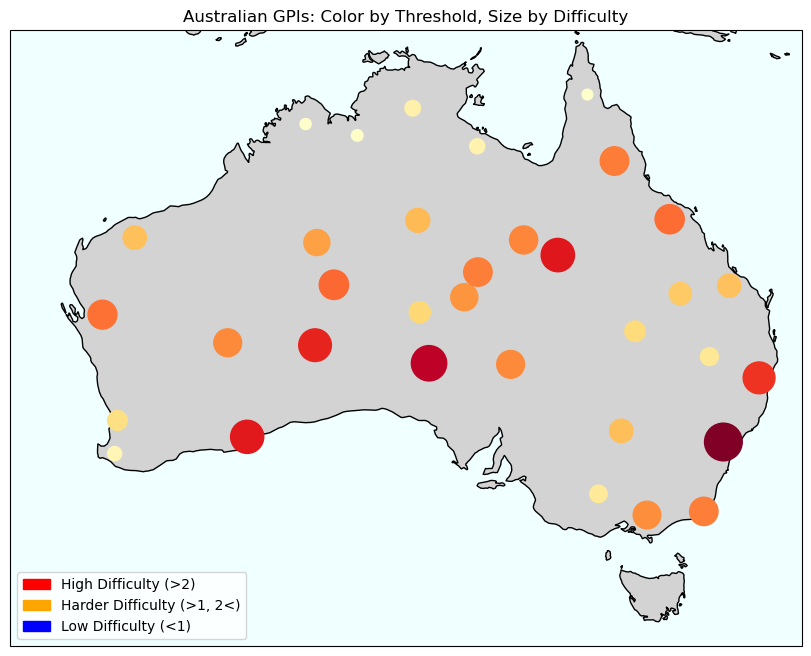

In [21]:
median_val = df_gpis['Difficulty_Index'].median()
p75_val = df_gpis['Difficulty_Index'].quantile(0.75)

colors = []
for val in df_gpis['Difficulty_Index']:
    if val >= 2:
        colors.append('red')
    elif val >= 1:
        colors.append('orange')
    else:
        colors.append('blue')

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='azure')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# cmap='YlOrRd', 
scale = 100
scatter = ax.scatter(
    df_gpis['Long'], df_gpis['Lat'],
    s=df_gpis['Difficulty_Index'] * scale,
    c=df_gpis['Difficulty_Index'],  
    cmap='YlOrRd',     
    transform=ccrs.PlateCarree(),
    zorder=5
)

red_patch = mpatches.Patch(color='red', label='High Difficulty (>2)')
darkred_patch = mpatches.Patch(color='orange', label='Harder Difficulty (>1, 2<)')
blue_patch = mpatches.Patch(color='blue', label='Low Difficulty (<1)')
plt.legend(handles=[red_patch, darkred_patch, blue_patch], loc='lower left')

plt.title("Australian GPIs: Color by Threshold, Size by Difficulty")
plt.show()

In [5]:
df_gpis['Difficulty_Index'].describe()

count    34.000000
mean      3.364035
std       1.752701
min       0.595462
25%       2.055381
50%       3.656676
75%       4.300072
max       7.360290
Name: Difficulty_Index, dtype: float64

# Modelling Statistics

In [22]:
df_results, df_feat = parse_model_logs('logs/a_rq1_slope_lagged_no_backscatter.txt')
df_results['GPI'] = df_results['GPI'].astype(int)
df_gpis['GPI'] = df_gpis['GPI'].astype(int)
df_results = pd.merge(df_results, df_gpis, on=['GPI', 'Target'])
df_results.head()

,GPI,Target,clim_rmse,clim_mae,clim_r2,clim_temporal_correlation,rand_rmse,rand_mae,rand_r2,rand_temporal_correlation,...,init_mae,init_r2,final_rmse,final_mae,final_r2,Lat,Long,Seasonality_Index,Volatility_Index,Difficulty_Index
0,2891016,slope40,0.00756,0.00638,-0.50647,0.43430,0.00869,0.00694,-0.99097,-0.00342,...,0.00456,0.22224,0.00403,0.00326,0.57079,-14.444257,132.880005,0.000551,0.000696,1.262556
1,2866040,slope40,0.00475,0.00390,0.39345,0.68368,0.00849,0.00675,-0.93745,0.02152,...,0.00366,0.51129,0.00265,0.00209,0.81164,-15.346562,126.794922,0.001158,0.000741,0.639406
2,2831296,slope40,0.01005,0.00866,0.32862,0.58387,0.01761,0.01430,-1.06041,-0.03843,...,0.00790,0.42683,0.00540,0.00464,0.80649,-16.608084,136.549072,0.000436,0.000509,1.168499
3,2912599,slope40,0.00658,0.00521,0.72337,0.88503,0.01743,0.01419,-0.94114,0.01875,...,0.00597,0.65495,0.00394,0.00313,0.90071,-13.667365,142.808517,0.000626,0.000373,0.595462
4,2808396,slope40,0.00641,0.00476,0.29889,0.64825,0.01068,0.00857,-0.94762,0.01620,...,0.00365,0.62872,0.00430,0.00338,0.68515,-17.443905,144.345825,0.000140,0.000588,4.209109


In [7]:
df_results['init_r2'].median()

np.float64(0.275395)

### Baseline Comparisons

In [8]:
model = "init"
df_results['Better_Than_Random'] = (
    (df_results[f'{model}_rmse'] < df_results['rand_rmse']) & 
    (df_results[f'{model}_mae'] < df_results['rand_mae']) & 
    (df_results[f'{model}_r2'] > df_results['rand_r2'])
)
df_results['Better_Than_Climatology'] = (
    (df_results[f'{model}_rmse'] < df_results['clim_rmse']) & 
    (df_results[f'{model}_mae'] < df_results['clim_mae']) & 
    (df_results[f'{model}_r2'] > df_results['clim_r2'])
)

if len(df_results[~df_results["Better_Than_Random"]]) > 0:
    print("Some predictions are worse than random sampled predictions")
if len(df_results[~df_results["Better_Than_Climatology"]]) > 0:
    print("Some predictions are worse than the climatology")

Some predictions are worse than random sampled predictions
Some predictions are worse than the climatology


In [9]:
len(df_results[~df_results["Better_Than_Random"]])

4

In [10]:
len(df_results[~df_results["Better_Than_Climatology"]])

7

### Modelling Improvements

In [11]:
metrics_dfs = {}
target_metrics = ['RMSE %', 'MAE %', 'R2 %']

all_impacts = []
for baseline_key, baseline_name in [("clim", "Climatology"), ("init", "Initial Model")]:
    temp = pd.DataFrame({
        'GPI': df_results['GPI'],
        'Target': df_results['Target'],
        'Comparison': baseline_name,
        'RMSE %': (df_results[f'{baseline_key}_rmse'] - df_results[f'{model}_rmse']) / df_results[f'{baseline_key}_rmse'] * 100,
        'MAE %': (df_results[f'{baseline_key}_mae'] - df_results[f'{model}_mae']) / df_results[f'{baseline_key}_mae'] * 100,
        'R2 %': (df_results[f'{model}_r2'] - df_results[f'{baseline_key}_r2']) / df_results[f'{baseline_key}_r2'].abs() * 100
    })
    all_impacts.append(temp)

df_impacts = pd.concat(all_impacts)

for m in target_metrics:
    summary = df_impacts.groupby(['Target', 'Comparison'])[m].agg(
        mean='mean',
        median='median',
        std='std',
        min='min',
        max='max'
    ).reset_index()

    metrics_dfs[m] = summary

print("--- RMSE Improvement Statistics ---")
display(metrics_dfs['RMSE %'].round(2))

print("--- MAE Improvement Statistics ---")
display(metrics_dfs['MAE %'].round(2))

print("--- R2 Improvement Statistics ---")
display(metrics_dfs['R2 %'].round(2))

--- RMSE Improvement Statistics ---


,Target,Comparison,mean,median,std,min,max
0,slope40,Climatology,20.2,17.6,20.96,-25.77,73.89
1,slope40,Initial Model,0.0,0.0,0.00,0.00,0.00


--- MAE Improvement Statistics ---


,Target,Comparison,mean,median,std,min,max
0,slope40,Climatology,20.83,21.24,22.36,-38.97,77.11
1,slope40,Initial Model,0.00,0.00,0.00,0.00,0.00


--- R2 Improvement Statistics ---


,Target,Comparison,mean,median,std,min,max
0,slope40,Climatology,1097.9,82.72,3968.59,-433.81,21821.85
1,slope40,Initial Model,0.0,0.00,0.00,0.00,0.00


/tmp/ipykernel_148/318749097.py:29: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


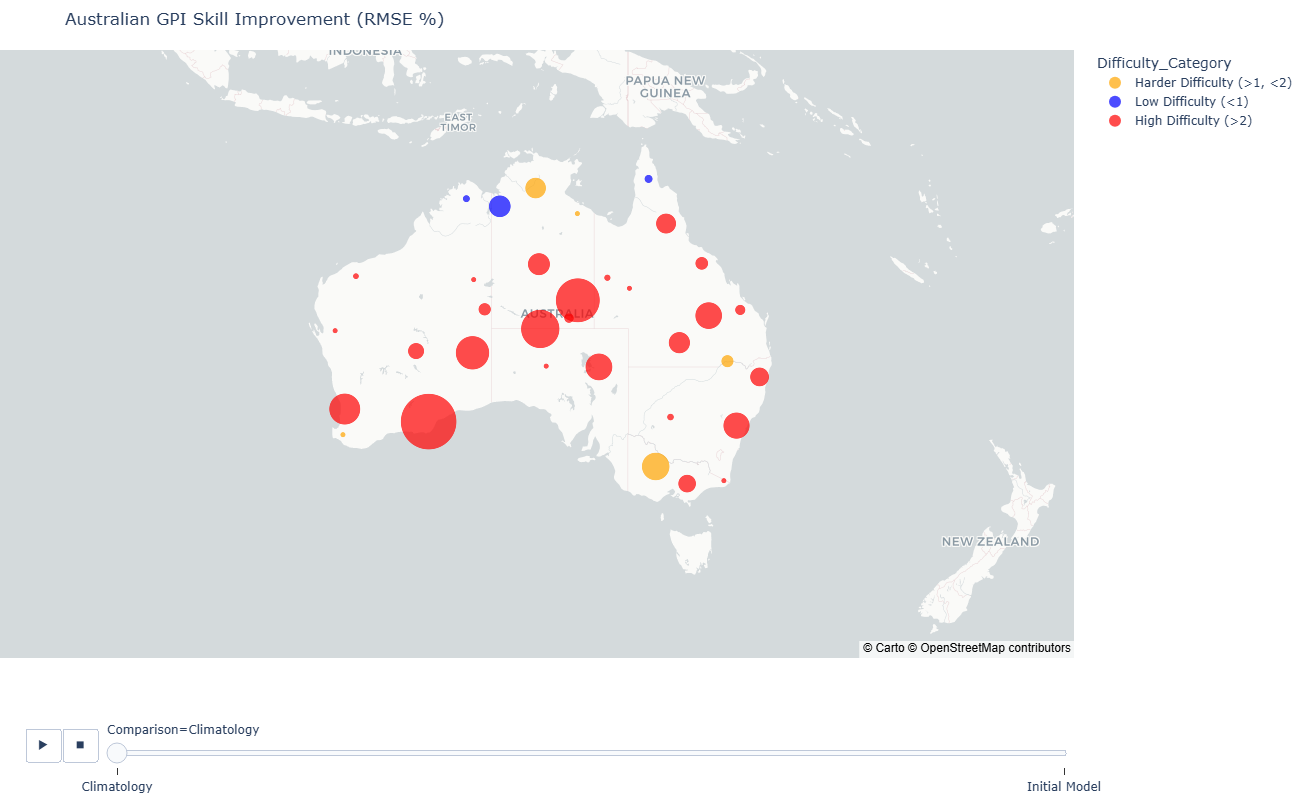

In [12]:
df_gpis['GPI'] = df_gpis['GPI'].astype(int)
df_impacts['GPI'] = df_impacts['GPI'].astype(int)
df_merged = pd.merge(df_gpis, df_impacts, on=['GPI', 'Target'])
df = df_merged.copy()


def get_color_label(val, p75, median):
    if val >= 2:
        return 'High Difficulty (>2)'
    elif val >= 1:
        return 'Harder Difficulty (>1, <2)'
    else:
        return 'Low Difficulty (<1)'


median_val = df['Difficulty_Index'].median()
p75_val = df['Difficulty_Index'].quantile(0.75)

df['Difficulty_Category'] = df['Difficulty_Index'].apply(
    lambda x: get_color_label(x, p75_val, median_val)
)

df['Visual_Size'] = (df['RMSE %'].abs()) ** 2
max_visual = df['Visual_Size'].max()
size_ref = max_visual / (40**2)

global_max_visual = df['Visual_Size'].max()

fig = px.scatter_mapbox(
    df,
    lat="Lat",
    lon="Long",
    color="Difficulty_Category",
    size="Visual_Size",
    hover_name="GPI",
    hover_data=["Target", "R2 %", "Difficulty_Index"],
    color_discrete_map={
        "High Difficulty (>2)": "red",
        "Harder Difficulty (>1, <2)": "orange",
        "Low Difficulty (<1)": "blue"
    },
    animation_frame="Comparison",
    zoom=3,
    center={"lat": -28, "lon": 133},
    title="Australian GPI Skill Improvement (RMSE %)",
    height=800,
    size_max=40
)

fig.update_traces(
    marker=dict(sizemode='area', sizemin=3),
    selector=dict(type='scattermapbox')
)

for frame in fig.frames:
    for data in frame.data:
        data.marker.sizemode = 'area'
        data.marker.sizemin = 3

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()


In [13]:
improvement_stats = df[df["Comparison"] != "Initial Model"].groupby('Difficulty_Category')['R2 %'].agg([
    'count',
    'mean',
    'median',
    'std'
]).sort_values(by='mean', ascending=False)

print("### Improvement Statistics by Difficulty Category ###")
improvement_stats.round(2)

### Improvement Statistics by Difficulty Category ###


,count,mean,median,std
Difficulty_Category,,,,
High Difficulty (>2),26,1417.16,95.28,4509.60
"Harder Difficulty (>1, <2)",5,90.52,29.89,114.91
Low Difficulty (<1),3,10.00,9.50,19.71


### Feature Importance

In [15]:
fi_cols = [c for c in df_feat.columns if (c != "GPI" and c != "Target")]
global_fi = df_feat.groupby('Target')[fi_cols].mean().T

print("--- Global Mean Feature Importance (Permutation Importance) ---")
print(global_fi.sort_values(by='slope40', ascending=False))

--- Global Mean Feature Importance (Permutation Importance) ---
Target        slope40
time_step    0.005988
cos_day      0.002278
LAI_lag14    0.002220
LAI_lag7     0.001913
year         0.001903
LAI          0.001703
sin_day      0.001461
swvl1        0.001325
swvl1_lag7   0.000597
swvl1_lag14  0.000333
stl1         0.000295
stl1_lag7    0.000232
stl1_lag14   0.000208
tp           0.000110
tp_lag14     0.000108
tp_lag7      0.000074


# RQ2

In [202]:
#australia_rq2 = [{'GPI': 2829466, 'Target': 'slope40', 'Lat': np.float32(-16.674746), 'Long': np.float32(135.75728), 'Seasonality_Index': np.float64(0.004902410761008745), 'Anomalies_Index': np.float64(0.006425379887004799), 'Difficulty_Index': np.float64(1.310657184850557)}, {'GPI': 2812454, 'Target': 'slope40', 'Lat': np.float32(-17.29553), 'Long': np.float32(137.83931), 'Seasonality_Index': np.float64(0.004914072946244649), 'Anomalies_Index': np.float64(0.005157575854979526), 'Difficulty_Index': np.float64(1.049552155899713)}, {'GPI': 2749129, 'Target': 'slope40', 'Lat': np.float32(-19.624855), 'Long': np.float32(136.99777), 'Seasonality_Index': np.float64(0.012841232784326542), 'Anomalies_Index': np.float64(0.0173583503843509), 'Difficulty_Index': np.float64(1.3517666625853677)}, {'GPI': 2799767, 'Target': 'slope40', 'Lat': np.float32(-17.759802), 'Long': np.float32(138.84181), 'Seasonality_Index': np.float64(0.0048788472142886116), 'Anomalies_Index': np.float64(0.00727640463359657), 'Difficulty_Index': np.float64(1.4914188360492753)}, {'GPI': 2752844, 'Target': 'slope40', 'Lat': np.float32(-19.487343), 'Long': np.float32(135.65433), 'Seasonality_Index': np.float64(0.005292256727755681), 'Anomalies_Index': np.float64(0.013085469482968376), 'Difficulty_Index': np.float64(2.4725689164587465)}, {'GPI': 2829466, 'Target': 'curvature40', 'Lat': np.float32(-16.674746), 'Long': np.float32(135.75728), 'Seasonality_Index': np.float64(0.00016183501102285462), 'Anomalies_Index': np.float64(0.0005634516167664103), 'Difficulty_Index': np.float64(3.4816422800307323)}, {'GPI': 2812454, 'Target': 'curvature40', 'Lat': np.float32(-17.29553), 'Long': np.float32(137.83931), 'Seasonality_Index': np.float64(0.00030830342014811753), 'Anomalies_Index': np.float64(0.00037948844850966196), 'Difficulty_Index': np.float64(1.230892762484909)}, {'GPI': 2749129, 'Target': 'curvature40', 'Lat': np.float32(-19.624855), 'Long': np.float32(136.99777), 'Seasonality_Index': np.float64(0.0006707962369932127), 'Anomalies_Index': np.float64(0.0009503909410288879), 'Difficulty_Index': np.float64(1.4168101855921775)}, {'GPI': 2799767, 'Target': 'curvature40', 'Lat': np.float32(-17.759802), 'Long': np.float32(138.84181), 'Seasonality_Index': np.float64(0.0005880024242027085), 'Anomalies_Index': np.float64(0.00054942056093505), 'Difficulty_Index': np.float64(0.934384856797193)}, {'GPI': 2752844, 'Target': 'curvature40', 'Lat': np.float32(-19.487343), 'Long': np.float32(135.65433), 'Seasonality_Index': np.float64(0.00045390935575822844), 'Anomalies_Index': np.float64(0.0009073180875520943), 'Difficulty_Index': np.float64(1.9988970838384101)}, {'GPI': 2762515, 'Target': 'slope40', 'Lat': np.float32(-19.12989), 'Long': np.float32(138.06819), 'Seasonality_Index': np.float64(0.005342945651622406), 'Anomalies_Index': np.float64(0.007529428423640361), 'Difficulty_Index': np.float64(1.4092279642324306)}, {'GPI': 2762515, 'Target': 'curvature40', 'Lat': np.float32(-19.12989), 'Long': np.float32(138.06819), 'Seasonality_Index': np.float64(0.0003312333234009389), 'Anomalies_Index': np.float64(0.0005608177915159418), 'Difficulty_Index': np.float64(1.6931200815115577)}]
australia_rq2 = [{'GPI': 2753022, 'Target': 'slope40', 'Lat': np.float32(-19.480757), 'Long': np.float32(139.27232), 'Seasonality_Index': np.float64(0.002905397827356569), 'Anomalies_Index': np.float64(0.006598235760687976), 'Difficulty_Index': np.float64(2.2710266038476656)}, {'GPI': 2812454, 'Target': 'slope40', 'Lat': np.float32(-17.29553), 'Long': np.float32(137.83931), 'Seasonality_Index': np.float64(0.004914072946244649), 'Anomalies_Index': np.float64(0.005157575854979526), 'Difficulty_Index': np.float64(1.049552155899713)}, {'GPI': 2721027, 'Target': 'slope40', 'Lat': np.float32(-20.668823), 'Long': np.float32(140.1831), 'Seasonality_Index': np.float64(0.0028275898995356015), 'Anomalies_Index': np.float64(0.00778136628955497), 'Difficulty_Index': np.float64(2.7519430207446165)}, {'GPI': 2716524, 'Target': 'slope40', 'Lat': np.float32(-20.836742), 'Long': np.float32(137.64462), 'Seasonality_Index': np.float64(0.007701467251513287), 'Anomalies_Index': np.float64(0.01450652710374953), 'Difficulty_Index': np.float64(1.883605633835435)}, {'GPI': 2722480, 'Target': 'slope40', 'Lat': np.float32(-20.61468), 'Long': np.float32(141.40195), 'Seasonality_Index': np.float64(0.02038612100352978), 'Anomalies_Index': np.float64(0.02524952337876476), 'Difficulty_Index': np.float64(1.2385643828167652)}, {'GPI': 2671842, 'Target': 'slope40', 'Lat': np.float32(-22.513083), 'Long': np.float32(139.5579), 'Seasonality_Index': np.float64(0.004746059762695692), 'Anomalies_Index': np.float64(0.006471975024098588), 'Difficulty_Index': np.float64(1.36365223947846)}, {'GPI': 2753022, 'Target': 'curvature40', 'Lat': np.float32(-19.480757), 'Long': np.float32(139.27232), 'Seasonality_Index': np.float64(0.00024260333128702465), 'Anomalies_Index': np.float64(0.0005012194684567001), 'Difficulty_Index': np.float64(2.0660040643205595)}, {'GPI': 2812454, 'Target': 'curvature40', 'Lat': np.float32(-17.29553), 'Long': np.float32(137.83931), 'Seasonality_Index': np.float64(0.00030830342014811753), 'Anomalies_Index': np.float64(0.00037948844850966196), 'Difficulty_Index': np.float64(1.230892762484909)}, {'GPI': 2721027, 'Target': 'curvature40', 'Lat': np.float32(-20.668823), 'Long': np.float32(140.1831), 'Seasonality_Index': np.float64(0.00017115607460329324), 'Anomalies_Index': np.float64(0.0005786331768206824), 'Difficulty_Index': np.float64(3.380734094082506)}, {'GPI': 2716524, 'Target': 'curvature40', 'Lat': np.float32(-20.836742), 'Long': np.float32(137.64462), 'Seasonality_Index': np.float64(0.00021511688883880608), 'Anomalies_Index': np.float64(0.0006686873362761453), 'Difficulty_Index': np.float64(3.1084836708344827)}, {'GPI': 2722480, 'Target': 'curvature40', 'Lat': np.float32(-20.61468), 'Long': np.float32(141.40195), 'Seasonality_Index': np.float64(0.0003485018412652535), 'Anomalies_Index': np.float64(0.000969655728497778), 'Difficulty_Index': np.float64(2.7823546784642343)}, {'GPI': 2671842, 'Target': 'curvature40', 'Lat': np.float32(-22.513083), 'Long': np.float32(139.5579), 'Seasonality_Index': np.float64(0.00012865783088959404), 'Anomalies_Index': np.float64(0.00040704656755619664), 'Difficulty_Index': np.float64(3.1637916226451703)}, {'GPI': 2800233, 'Target': 'slope40', 'Lat': np.float32(-17.74273), 'Long': np.float32(140.22375), 'Seasonality_Index': np.float64(0.01177765724021438), 'Anomalies_Index': np.float64(0.011740610579788842), 'Difficulty_Index': np.float64(0.9968544966397015)}, {'GPI': 2800233, 'Target': 'curvature40', 'Lat': np.float32(-17.74273), 'Long': np.float32(140.22375), 'Seasonality_Index': np.float64(0.0008286431992602133), 'Anomalies_Index': np.float64(0.0009741318592866392), 'Difficulty_Index': np.float64(1.175574553868678)}]
#australia_rq2 = get_gpi_meta_info([2608428, 2594055, 2611766, 2612609, 2621204, 2637085, 2638682])

gpi_dict_rq2 = {}
for item in australia_rq2:
    gpi = item['GPI']
    target = item['Target']
    if gpi not in gpi_dict_rq2:
        gpi_dict_rq2[gpi] = {}
    gpi_dict_rq2[gpi][target] = {k: v for k, v in item.items() if k not in ['GPI', 'Target']}

df_gpis_rq2 = pd.DataFrame([
    {'GPI': gpi, 'Target': target, **metrics}
    for gpi, targets in gpi_dict_rq2.items()
    for target, metrics in targets.items()
])

df_results_rq2 = parse_model_logs_rq2('logs/australia_rq2_gpi_set_2_recent.txt')
df_gpis_rq2 = df_gpis_rq2[df_gpis_rq2["Target"] == "slope40"]
df_gpis_rq2

,GPI,Target,Lat,Long,Seasonality_Index,Anomalies_Index,Difficulty_Index
0,2753022,slope40,-19.480757,139.272324,0.002905,0.006598,2.271027
2,2812454,slope40,-17.295530,137.839310,0.004914,0.005158,1.049552
4,2721027,slope40,-20.668823,140.183105,0.002828,0.007781,2.751943
6,2716524,slope40,-20.836742,137.644623,0.007701,0.014507,1.883606
8,2722480,slope40,-20.614679,141.401947,0.020386,0.025250,1.238564
10,2671842,slope40,-22.513083,139.557907,0.004746,0.006472,1.363652
12,2800233,slope40,-17.742729,140.223755,0.011778,0.011741,0.996854


In [203]:
df_results_rq2

,GPI,is_origin,local_model_rmse,local_model_mae,local_model_r2,origin_model_rmse,origin_model_mae,origin_model_r2,climatology_rmse,climatology_mae,climatology_r2,random_noise_rmse,random_noise_mae,random_noise_r2
0,2671842,False,0.00571,0.00450,-0.27251,0.00473,0.00392,0.12559,0.00521,0.00427,-0.05888,0.00716,0.00577,-1.00298
1,2716524,False,0.00835,0.00631,0.38022,0.00852,0.00651,0.35479,0.01016,0.00863,0.08149,0.01487,0.01193,-0.96514
2,2721027,False,0.00513,0.00428,-0.02067,0.00488,0.00368,0.07560,0.00539,0.00426,-0.12656,0.00707,0.00561,-0.93971
3,2722480,False,0.01113,0.00881,0.81631,0.01912,0.01619,0.45802,0.02674,0.02349,-0.05970,0.03651,0.02877,-0.97537
4,2753022,True,0.00468,0.00385,-0.63672,0.00468,0.00385,-0.63672,0.00689,0.00595,-2.54334,0.00511,0.00408,-0.95548
5,2800233,False,0.01003,0.00789,0.62473,0.01452,0.01126,0.21357,0.00955,0.00800,0.65947,0.02328,0.01870,-1.02354
6,2812454,False,0.00428,0.00343,0.62503,0.00604,0.00488,0.25528,0.00459,0.00374,0.56911,0.00996,0.00800,-1.02781


In [204]:
model = "origin_model"
df_results_rq2['Better_Than_Random'] = (
    (df_results_rq2[f'{model}_rmse'] < df_results_rq2['random_noise_rmse']) & 
    (df_results_rq2[f'{model}_mae'] < df_results_rq2['random_noise_mae']) & 
    (df_results_rq2[f'{model}_r2'] > df_results_rq2['random_noise_r2'])
)
df_results_rq2['Better_Than_Climatology'] = (
    (df_results_rq2[f'{model}_rmse'] < df_results_rq2['climatology_rmse']) & 
    (df_results_rq2[f'{model}_mae'] < df_results_rq2['climatology_mae']) & 
    (df_results_rq2[f'{model}_r2'] > df_results_rq2['climatology_r2'])
)

if len(df_results_rq2[~df_results_rq2["Better_Than_Random"]]) > 0:
    print("Some predictions are worse than random sampled predictions")
if len(df_results_rq2[~df_results_rq2["Better_Than_Climatology"]]) > 0:
    print("Some predictions are worse than the climatology")

Some predictions are worse than the climatology


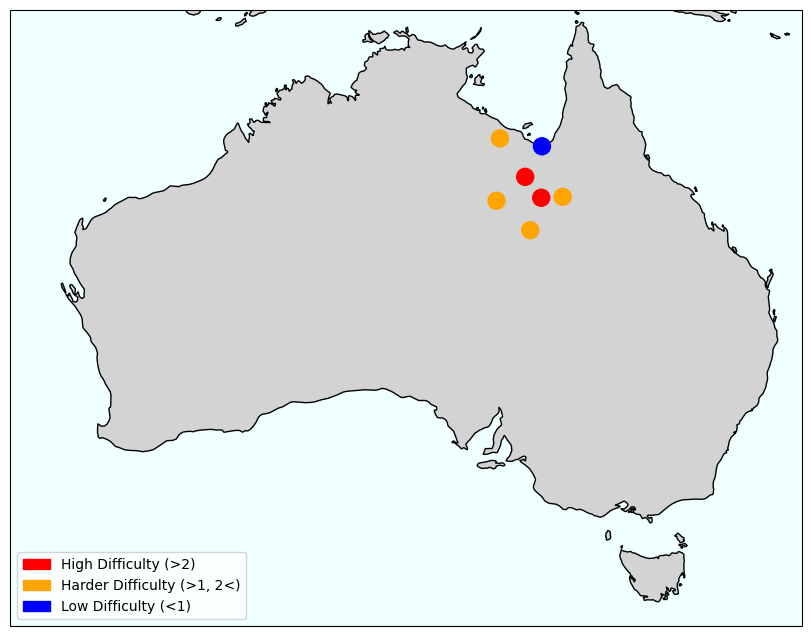

In [205]:
median_val = df_gpis['Difficulty_Index'].median()
p75_val = df_gpis['Difficulty_Index'].quantile(0.75)

colors = []
for val in df_gpis_rq2['Difficulty_Index']:
    if val >= 2:
        colors.append('red')
    elif val >= 1:
        colors.append('orange')
    else:
        colors.append('blue')

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='azure')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

scale = 100
scatter = ax.scatter(
    df_gpis_rq2['Long'], df_gpis_rq2['Lat'],
    s=150,
    c=colors,
    transform=ccrs.PlateCarree(),
    zorder=5
)

red_patch = mpatches.Patch(color='red', label='High Difficulty (>2)')
darkred_patch = mpatches.Patch(color='orange', label='Harder Difficulty (>1, 2<)')
blue_patch = mpatches.Patch(color='blue', label='Low Difficulty (<1)')
plt.legend(handles=[red_patch, darkred_patch, blue_patch], loc='lower left')
plt.savefig('difficulty_map_set3.png', dpi=300, bbox_inches='tight')
plt.show()

In [206]:
# Calculate absolute differences
df_results_rq2['rmse_diff'] = df_results_rq2['origin_model_rmse'] - df_results_rq2['local_model_rmse']
df_results_rq2['mae_diff'] = df_results_rq2['origin_model_mae'] - df_results_rq2['local_model_mae']
df_results_rq2['r2_diff'] = df_results_rq2['local_model_r2'] - df_results_rq2['origin_model_r2']

# Average drop in performance across all surrounding points
summary = df_results_rq2[df_results_rq2['is_origin'] == False][['rmse_diff', 'mae_diff', 'r2_diff']].mean()
print("Average Performance Loss:")
print(summary)

Average Performance Loss:
rmse_diff    0.002197
mae_diff     0.001870
r2_diff      0.111710
dtype: float64


In [207]:
df_results_rq2
# diff negativ: reused besser als local
# diff positiv: local besser al reused

,GPI,is_origin,local_model_rmse,local_model_mae,local_model_r2,origin_model_rmse,origin_model_mae,origin_model_r2,climatology_rmse,climatology_mae,climatology_r2,random_noise_rmse,random_noise_mae,random_noise_r2,Better_Than_Random,Better_Than_Climatology,rmse_diff,mae_diff,r2_diff
0,2671842,False,0.00571,0.00450,-0.27251,0.00473,0.00392,0.12559,0.00521,0.00427,-0.05888,0.00716,0.00577,-1.00298,True,True,-0.00098,-0.00058,-0.39810
1,2716524,False,0.00835,0.00631,0.38022,0.00852,0.00651,0.35479,0.01016,0.00863,0.08149,0.01487,0.01193,-0.96514,True,True,0.00017,0.00020,0.02543
2,2721027,False,0.00513,0.00428,-0.02067,0.00488,0.00368,0.07560,0.00539,0.00426,-0.12656,0.00707,0.00561,-0.93971,True,True,-0.00025,-0.00060,-0.09627
3,2722480,False,0.01113,0.00881,0.81631,0.01912,0.01619,0.45802,0.02674,0.02349,-0.05970,0.03651,0.02877,-0.97537,True,True,0.00799,0.00738,0.35829
4,2753022,True,0.00468,0.00385,-0.63672,0.00468,0.00385,-0.63672,0.00689,0.00595,-2.54334,0.00511,0.00408,-0.95548,True,True,0.00000,0.00000,0.00000
5,2800233,False,0.01003,0.00789,0.62473,0.01452,0.01126,0.21357,0.00955,0.00800,0.65947,0.02328,0.01870,-1.02354,True,False,0.00449,0.00337,0.41116
6,2812454,False,0.00428,0.00343,0.62503,0.00604,0.00488,0.25528,0.00459,0.00374,0.56911,0.00996,0.00800,-1.02781,True,False,0.00176,0.00145,0.36975


In [ ]:
'RMSE %': (df_results[f'{baseline_key}_rmse'] - df_results[f'{model}_rmse']) / df_results[f'{baseline_key}_rmse'] * 100,
'MAE %': (df_results[f'{baseline_key}_mae'] - df_results[f'{model}_mae']) / df_results[f'{baseline_key}_mae'] * 100,
'R2 %': (df_results[f'{model}_r2'] - df_results[f'{baseline_key}_r2']) / df_results[f'{baseline_key}_r2'].abs() * 100

In [208]:
# Calculate % increase in error (Lower is better, so positive % means performance of reused model got worse)
df_results_rq2['rmse_loss_pct'] = ((df_results_rq2['origin_model_rmse'] - df_results_rq2['local_model_rmse']) / df_results_rq2['local_model_rmse']) * 100
df_results_rq2['mae_loss_pct'] = ((df_results_rq2['origin_model_mae'] - df_results_rq2['local_model_mae']) / df_results_rq2['local_model_mae']) * 100
df_results_rq2['r2_loss_pct'] = ((df_results_rq2['local_model_r2'] - df_results_rq2['origin_model_r2']) / df_results_rq2['local_model_r2'].abs()) * 100

# Select and display
percentage_report = df_results_rq2[df_results_rq2['is_origin'] == False][['GPI', 'rmse_loss_pct', 'mae_loss_pct', 'r2_loss_pct']]
print(percentage_report)


       GPI  rmse_loss_pct  mae_loss_pct  r2_loss_pct
0  2671842     -17.162872    -12.888889  -146.086382
1  2716524       2.035928      3.169572     6.688233
2  2721027      -4.873294    -14.018692  -465.747460
3  2722480      71.787960     83.768445    43.891414
5  2800233      44.765703     42.712294    65.814032
6  2812454      41.121495     42.274052    59.157160


In [209]:
df_subset = percentage_report[[col for col in percentage_report.columns if col != 'GPI']]
df_subset.median()

rmse_loss_pct    21.578712
mae_loss_pct     22.721812
r2_loss_pct      25.289823
dtype: float64

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


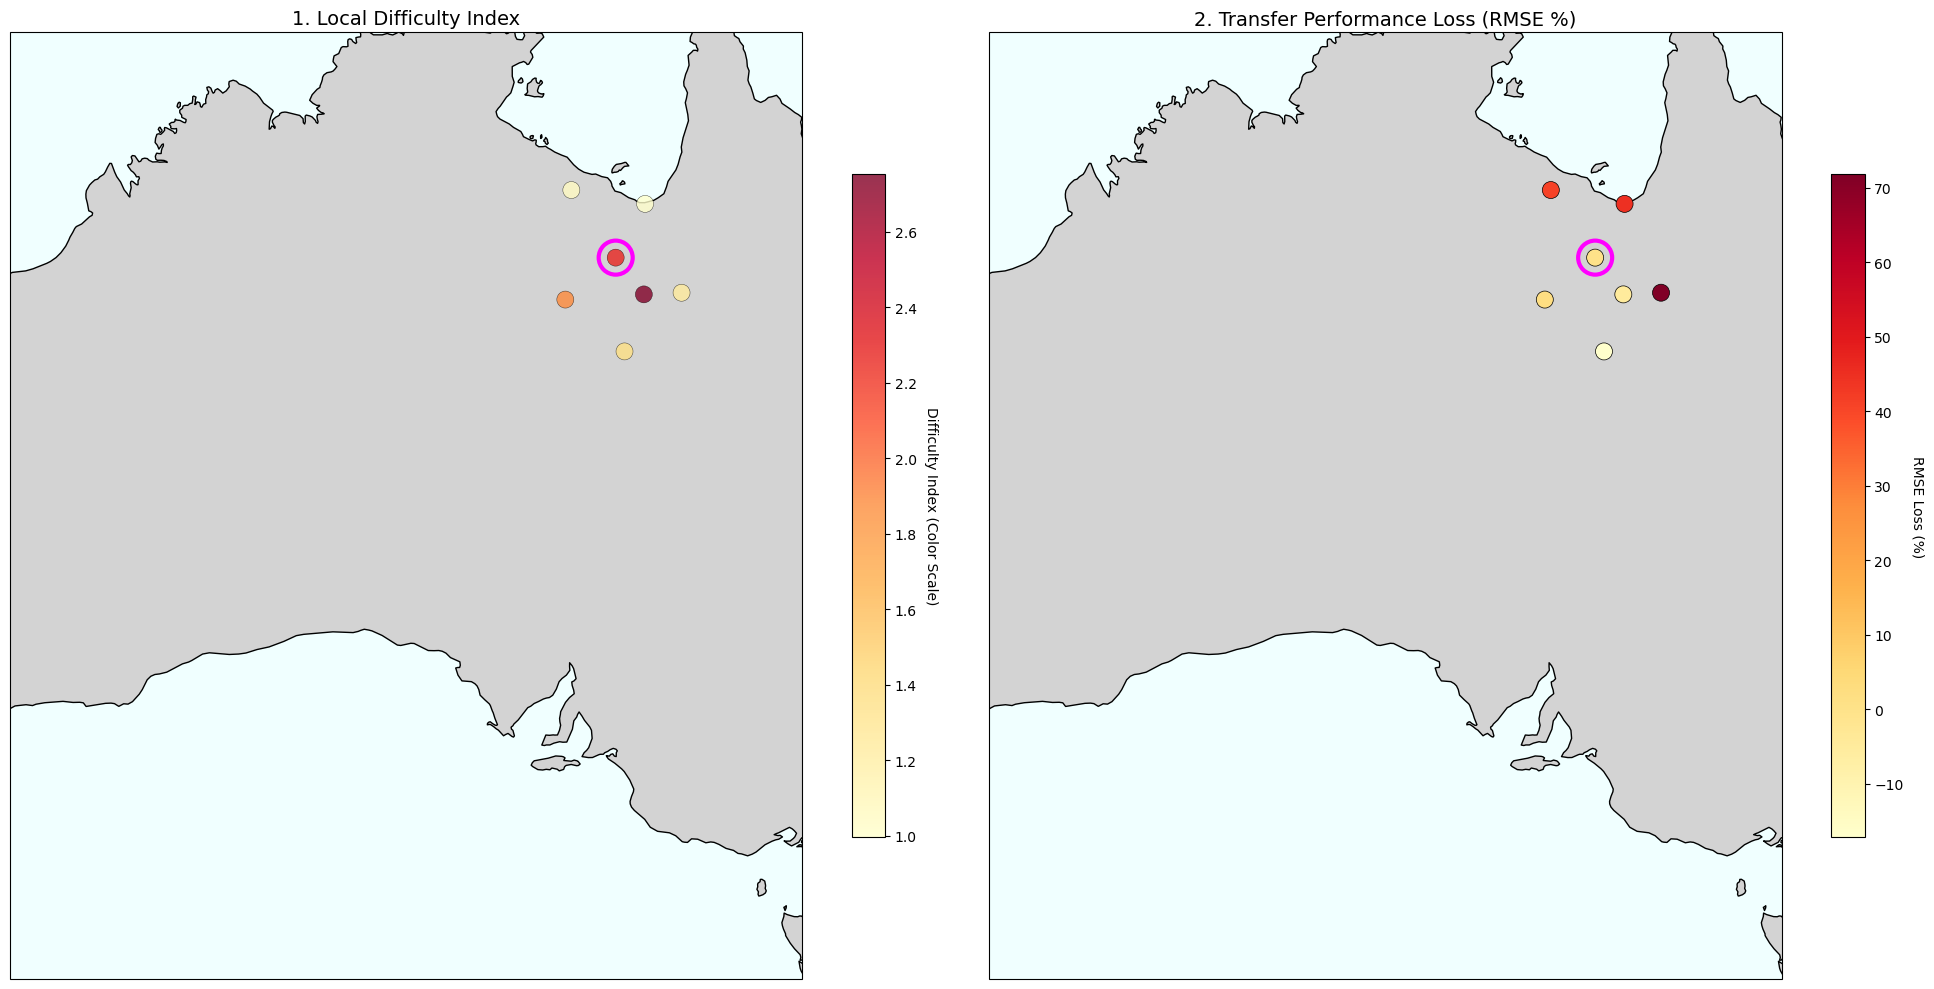

In [210]:
df_gpis_rq2['GPI'] = df_gpis_rq2['GPI'].astype(int)
df_results_rq2['GPI'] = df_results_rq2['GPI'].astype(int)
df_results = pd.merge(df_results_rq2, df_gpis_rq2, on=['GPI'])

plot_model_reuse(df_results)